---
# Score-Based Generative Modeling
---

In this exercise, we will implement a Diffusion Model through Stochastic Differential Equations (SDE). 

For this task we highly recommend to use a GPU, as the training of the models can take a long time on CPU.

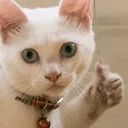

Diffusion models can also be formulated from a score-based perspective. Instead of directly predicting the added noise as in DDPMs, the model learns the score function, i.e. the gradient of the log-density of the noised data distribution. The forward process is described by a stochastic differential equation (SDE) that radually perturbs data into noise. Sampling is then performed by approximately reversing this SDE, using the learned score model to guide noisy samples back toward the data distribution.

You do not need to read the papers to complete the exercise, but it is highly recommended to read them to gain a deeper understanding of the concepts and techniques involved in diffusion models.

Paper: [Score-Based Generative Modeling through Stochastic Differential Equations](https://arxiv.org/abs/2011.13456)

---
# Imports
---

Run the code cell below after you have set up everything correctly (either locally or in Colab).

In [1]:
import importlib
import torch

import data
import trainer
import utils
import visual
import tests
import models

---
## Score-Based SDE Forward Process
---

In a score-based diffusion model, the **forward process** is defined in continuous time. Instead of adding noise over discrete steps as in DDPMs, the data distribution is gradually transformed into a Gaussian prior by a stochastic differential equation (SDE).

In general, the forward SDE can be written as:
$$dx = f(x,t)dt + g(t)dw,$$
where $f(x,t)$ is the drift coefficient, $g(t)$ is the diffusion coefficient, and $w$ is a standard Wiener process. The choice of $f$ and $g$ defines the specific SDE used for the forward process.
A common choice is the **Variance Preserving SDE (VP-SDE)**, which is the continuous-time analogue of DDPM:
$$
dx =
-\frac{1}{2}\beta(t)x\,dt
+
\sqrt{\beta(t)}\,dw,
$$

where $\beta(t)$ is a continuous noise schedule, typically $\beta(t) = \beta_{start} + t(\beta_{end}-\beta_{start}), t \in [0,1]$.

The forward process defines a perturbation distribution $p_{0t}(x(t) \mid x(0))$, which describes how to sample a noisy version $x_t$ directly from a clean sample $x_0$.

For the VP-SDE, this marginal distribution has the closed form
$$
p_{0t}(x(t) \mid x(0))
=
\mathcal{N}
\left(
x(t)
\mid
\mu(t)x(0),
\sigma^2(t)I
\right),
$$
with $\mu(t) = \exp\left(-\frac{1}{2}\int_0^t \beta(s)\,ds\right)$ and
$\sigma^2(t) = 1 - \exp\left(-\int_0^t \beta(s)\,ds\right)$.
For a linear noise schedule, the integral is $\int_0^t \beta(s)\,ds = \beta_{start}t + \frac{1}{2} (\beta_{end}-\beta_{start})t^2$.
Therefore, $x_t$ can be sampled directly as
$$
x(t)
=
\mu(t)x(0)
+
\sigma(t)\varepsilon,
\qquad
\varepsilon \sim \mathcal{N}(0,I).
$$

## **Task:**

Implement `vp_coeffs`, `marginal_prob`, and `q_sample` in `utils.py`.

In [2]:
importlib.reload(utils)

tests.test_vp_coeffs()
tests.test_marginal_prob()
tests.test_vp_q_sample()


✅ PASS: vp_coeffs seems to be correct.
✅ PASS: marginal_prob seems to be correct.
✅ PASS: VP q_sample seems to be correct.


True

---
## Visualize the Forward Noising Process
---

After implementing `q_sample`, the following cell shows how a clean image is gradually destroyed by the forward process.

In [3]:
_, val_loader, _ = data.make_afhq_loaders(batch_size=16, num_workers=0, image_size=32)
x, _ = next(iter(val_loader))

x0 = x[:1]
noise = torch.randn_like(x0)

noised_images = []
for t in torch.linspace(0, 1, steps=6):
    noised_images.append(utils.q_sample(x0, t.unsqueeze(0), noise))

noised_images = torch.cat(noised_images, dim=0).cpu()
visual._image_grid(noised_images, title="VP-SDE forward noising process", cols=6)

AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


---
## VP-SDE Sampling
---

VP-SDE sampling starts from pure Gaussian noise and follows the learned reverse-time SDE back to the data distribution.

During training, the model learns to predict the score

$$
s_\theta(x(t),t)
\approx
\nabla_{x(t)} \log p_t(x(t)).
$$

During sampling, we use this score to reverse the forward diffusion process.  
For a general forward SDE $dx = f(x,t)dt + g(t)dw$, the corresponding reverse-time SDE is
$$
dx =
\left[
f(x,t)
-
g^2(t)s_\theta(x,t)
\right]dt
+
g(t)d\bar{w},
$$

where $d\bar{w}$ denotes a Wiener process in reverse time.

To sample from the model, we start with $x(1) \sim \mathcal{N}(0,I)$, and discretize time from $t=1$ to $t=0$ using a small step size $\Delta t = \frac{1}{N}$.

The reverse-time SDE can be discretized using Euler-Maruyama, one reverse sampling step from $t$ to $t-\Delta t$ is
$$
x(t-\Delta t) = x(t) - \left[f(x(t),t) - g^2(t)s_\theta(x(t),t) \right]\Delta t + g(t)\,\sqrt{\Delta_t}\,z,\qquad z \sim \mathcal{N}(0,I).
$$

## **Task:**

Implement `vp_sde_sample` in `utils.py`.

**Hints:**
- $t$ should range from $[1, \varepsilon]$ for every batch element.
- The last ste
- For DDPM-style sinusoidal embeddings, we pass t * 999 to the U-Net so that the embedding receives values on the usual DDPM timestep scale.

In [4]:
importlib.reload(utils)

tests.test_vp_sde_sample()

✅ PASS: vp_sde_sample seems to be correct.


True

---
## Score-Based SDE Training
---

During training, we use the closed-form perturbation distribution of the forward SDE. For each clean image $x(0)$, we sample a random time $t \in [0,1]$ and Gaussian noise $z \sim \mathcal{N}(0,I)$.

For the Gaussian perturbation kernel, the target score is
$$
\nabla_{x(t)} \log p_{0t}(x(t) \mid x(0)) =
- \frac{x(t) - \mu(t)x(0)}{\sigma^2(t)}
= - \frac{z}{\sigma(t)}.
$$

Thus, the model is trained to predict

$$
s_\theta(x(t),t)
\approx
-
\frac{z}{\sigma(t)}.
$$

Instead of explicitly dividing by small values of $\sigma(t)$, we use the weighted denoising score matching loss

$$
\mathcal{L}_{score}
=
\mathbb{E}_{x(0),t,z}
\left[
\left\lVert
\sigma(t)s_\theta(x(t),t) + z
\right\rVert_2^2
\right].
$$

This objective trains the network to estimate the score at different noise levels.

Now we need to create the data loaders, initialize the U-Net, train the score model using the VP-SDE perturbation process, and evaluate it on the validation set.

## **Task:**

Implement `train_score_sde` in `trainer.py`.

**Hints:**
- Use `AdamW` as the optimizer.
- Sample $t$ uniformly from $[\varepsilon,1]$ for every batch element.
- For DDPM-style sinusoidal embeddings, we pass t * 999 to the U-Net so that the embedding receives values on the usual DDPM timestep scale.
- Generate and display some samples every few epochs. This helps monitor whether the reverse SDE gradually produces meaningful images instead of pure noise.

In [5]:
importlib.reload(trainer)
importlib.reload(data)
importlib.reload(models)

# Hyperparameters. Adjust these values to tune training.

lr = 2e-4
betas=(0.9, 0.999)
weight_decay = 1e-5

num_timesteps = 1000
base_channels = 64
time_dim = 256
groups = 8

beta_start = 0.1
beta_end = 20
eps = 5e-4
num_steps = 1000

batch_size = 64
epochs = 100
image_size = 32
num_workers = 2

device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() else "cpu")
print(f"Using device: {device}")

model, history = trainer.train_score_sde(
    base_channels=base_channels, 
    time_dim=time_dim, 
    groups=groups, 
    batch_size=batch_size, 
    lr=lr, 
    betas=betas, 
    weight_decay=weight_decay, 
    epochs=epochs, 
    device=device, 
    num_workers=num_workers, 
    image_size=image_size, 
    beta_start=beta_start, 
    beta_end=beta_end, 
    eps=eps, 
    num_steps=num_steps)

visual.show_training_stats(history, title="VP-SDE Training").show()

Using device: cuda:0
AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


Training VP-SDE model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 97/100:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100/100 - Train Loss: 120.5907 - Val Loss: 149.6308


---
## Visualize the Reverse Denoising Process
---

In [6]:
model.eval()
samples, samples_trajectories = utils.vp_sde_sample(model, 16, image_size, num_steps, eps, device, beta_start=beta_start, beta_end=beta_end)

visual.animate_trajectories(samples_trajectories, title="VP-SDE reverse sampling process", savepath="vp_sde.gif", fps=200)
visual._image_grid(samples, title="VP-SDE generated samples", cols=4).show()